# Surrogate-model comparison on heteroscedastic mixed-variable test problems

**Goal.** Compare four surrogate models for *heteroscedastic mixed-variable* data (continuous
inputs $\times$ one categorical input with noisy, replicated observations) on ground-truth-based
modeling metrics — **no BO loop**, pure modeling quality over the whole domain.

| # | model | engine | idea | noise treatment |
|---|-------|--------|------|-----------------|
| 1 | **Separate GPs** | python (botorch) | one independent GP per categorical level | replicate variance as fixed noise, per level |
| 2 | **Categorical GP** | python (botorch) | single GP, categorical kernel over levels | replicate variance as fixed noise |
| 3 | **Standard LVGP** | **MATLAB** (`LVGP_fit`) | latent-variable GP (Zhang et al., 2019), homoscedastic | none — the noise-blind baseline |
| 4 | **H-LVGP** | **MATLAB** (`LVGP_fit_noise`) | heteroscedastic LVGP (the lab's model) | replicate variances inside the correlation matrix + pooled aleatoric polynomial |

The two LVGP columns are the **MATLAB implementations of record** (the postdoc's code, called
unmodified through the `matlab/mfit.m` / `matlab/mpredict.m` bridge — a `matlab -batch`
subprocess per fit / prediction batch). No python LVGP port is used anywhere in this study.

**Test problems** (each provides analytic $f_{\mathrm{true}}(\mathbf{x},\ell)$ *and* analytic
noise $\sigma(\mathbf{x},\ell)$, so every metric is scored against exact ground truth):

1. **`branin_hetero`** — 1 continuous input $\times$ 5 levels (levels far apart / easy to tell apart).
2. **`sixhump_camel`** — 1 continuous input $\times$ 4 levels (levels close together / hard to tell apart).
3. **`rastrigin_6d`** — 5 continuous inputs + 1 categorical = 6-D input space, 4 levels.

**Metrics** (per level + mean): MAE, RRMSE, 90% Interval Score (IS), 90% Coverage.

> All heavy fits are cached under `results/pred_cache/` (`utils/study.py`); re-running this
> notebook is cheap. Delete a cache file to force a refit.

In [1]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils import problems as P, doe_cache, study, metrics as MET
from utils.models import MODELS

MODEL_KEYS = ["separate_gp", "categorical_kernel", "standard_LVGP", "heter_LVGP"]
LABELS = {"separate_gp": "Separate GPs", "categorical_kernel": "Categorical GP",
          "standard_LVGP": "Standard LVGP", "heter_LVGP": "H-LVGP"}
COLORS = {"separate_gp": "#3d6f9e", "categorical_kernel": "#8a5fa8",
          "standard_LVGP": "#c07a3a", "heter_LVGP": "#2e8b6e"}
SEED, N_REP = 1, 10            # headline tables: n_rep = 10 replicates/location, one seed
N_REPS = [3, 10]               # replicate axis compared in section 8
NBIG = 32                      # "moderate" 1-D budget: 8 pts/level for camel; branin uses 40
N40 = 40
NMID_B, NMID_C, NMID_R = 25, 20, 20   # "middle" budgets: ~5 pts/level for each problem
NR80, NR160 = 80, 160                  # rastrigin-only larger budgets (20 and 40 pts/level)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

---
## 1&nbsp;&nbsp;Test problems

### 1.1&nbsp; `branin_hetero` — 1 continuous input, 5 levels (well-separated levels)

The Branin function with $x_2$ frozen per categorical level and a strongly heteroscedastic,
level- and $x$-dependent noise:

$$f(x_1,\ell)=\Big(x_2(\ell)-\tfrac{5.1}{4\pi^2}x_1^2+\tfrac{5}{\pi}x_1-6\Big)^2
+10\Big(1-\tfrac{1}{8\pi}\Big)\cos x_1+10,\qquad x_1\in[-5,10]$$

$$\sigma(x_1,\ell)=\underbrace{0.135\,e^{(0.15x_1)^2}}_{\text{base noise}}\times
\underbrace{m(\ell)}_{\text{level multiplier}},\qquad
x_2(\ell)\in\{15,\,2,\,8,\,0,\,10\},\quad m(\ell)\in\{10.0,\,7.0,\,9.0,\,5.0,\,12.0\}$$

$$y(x_1,\ell)=f(x_1,\ell)+\varepsilon,\qquad \varepsilon\sim\mathcal N\big(0,\sigma^2(x_1,\ell)\big)$$

Why it is a good low-dimensional test:
* **Level structure to recover** — levels $\{2,4\}$ ($x_2$ = 2, 0) are similar to each other and
  dissimilar from $\{1,3,5\}$: exactly the similarity geometry an LVGP latent space should learn,
  and what the separate-GP baseline (no sharing) must pay for in sample efficiency.
* **Strong, smooth heteroscedasticity** — noise grows $\propto e^{(0.15x_1)^2}$ toward the
  domain edges and the level multiplier spans 5–12 (2.4×), so noise-blind models get visibly
  mis-calibrated.
* Level responses differ by **hundreds of $y$-units** — cross-level sharing helps but a model
  must not blur levels together.

### 1.2&nbsp; `sixhump_camel` — 1 continuous input, 4 levels (closely-spaced levels)

The six-hump camel-back with $x_2$ frozen per level, on $x_1\in[-2,2]$:

$$f(x_1,\ell)=\Big(4-2.1x_1^2+\tfrac{x_1^4}{3}\Big)x_1^2+x_1\,x_2(\ell)+\big(-4+4x_2(\ell)^2\big)x_2(\ell)^2$$

$$\sigma(x_1,\ell)=0.05\,e^{(0.4x_1)^2}\,m(\ell),\qquad
x_2(\ell)\in\{0.2,\,0.4,\,0.7,\,1.0\},\quad m(\ell)\in\{2.0,\,3.5,\,1.5,\,5.0\}$$

Why it complements Branin:
* **Levels are close and ordered** — the four response curves nearly overlap (differences of order
  1 $y$-unit) and shift monotonically with $x_2$: level *discrimination* is now the hard part,
  the opposite regime from Branin's widely-separated levels. A model that blurs levels pays little
  here in MAE — but a model that shares strength across levels gains a lot.
* **The most extreme noise ratios** of the 1-D suite — $m(\ell)$ spans 1.5 to 5.0 (a 3.3× spread),
  and at the domain edges $\sigma$ rivals the *between-level* signal differences: the
  heteroscedastic treatment is genuinely stressed.
* Signal-to-noise is much lower than Branin's relative to level separation — coverage/IS now
  hinge on honest uncertainty rather than raw accuracy.

### 1.3&nbsp; `rastrigin_6d` — 5 continuous inputs + 1 categorical = 6-D (multi-dimensional)

A level-shifted Rastrigin: each level $\ell$ has its own minimizer location
$\mathbf{c}(\ell) \in \mathbb{R}^5$ and offset $b(\ell)$:

$$f(\mathbf{x},\ell)=\sum_{i=1}^{5}\Big[(x_i-c_i(\ell))^2-10\cos\!\big(2\pi(x_i-c_i(\ell))\big)+10\Big]+b(\ell),
\qquad \mathbf{x}\in[-5,5]^5$$

$$\sigma(\mathbf{x},\ell)=\sqrt{1+0.05\,\overline{x^2}}\;m(\ell),\qquad
b(\ell)\in\{5,20,40,65\},\quad m(\ell)\in\{1.0,2.0,1.5,3.0\}$$

Why it is a good multi-dimensional test:
* **Rugged multimodal surface** ($\pm10\cos$ ripples in every dimension) — a stress test for a
  stationary Gaussian kernel with n = 32 training points; separates models by how gracefully they
  degrade.
* **Levels differ in both location and value** of their optima — the categorical dimension is
  *not* a simple output shift, so naive pooling is wrong and the latent embedding is genuinely
  challenged.
* In the parent BO benchmark this is the problem where the simple categorical-kernel GP beat both
  LVGPs — a result this modeling study probes directly.

In [2]:
spec1 = P.get("branin_hetero"); specC = P.get("sixhump_camel"); spec6 = P.get("rastrigin_6d")
for s in (spec1, specC, spec6):
    print(f"{s.name:15s} d={s.d} continuous + 1 categorical ({s.n_levels} levels)   "
          f"n_init={s.n_init} design points ({s.n_init//s.n_levels}/level)   bounds={s.bounds[0]}")

branin_hetero   d=1 continuous + 1 categorical (5 levels)   n_init=10 design points (2/level)   bounds=[-5. 10.]
sixhump_camel   d=1 continuous + 1 categorical (4 levels)   n_init=8 design points (2/level)   bounds=[-2.  2.]
rastrigin_6d    d=5 continuous + 1 categorical (4 levels)   n_init=32 design points (8/level)   bounds=[-5.  5.]


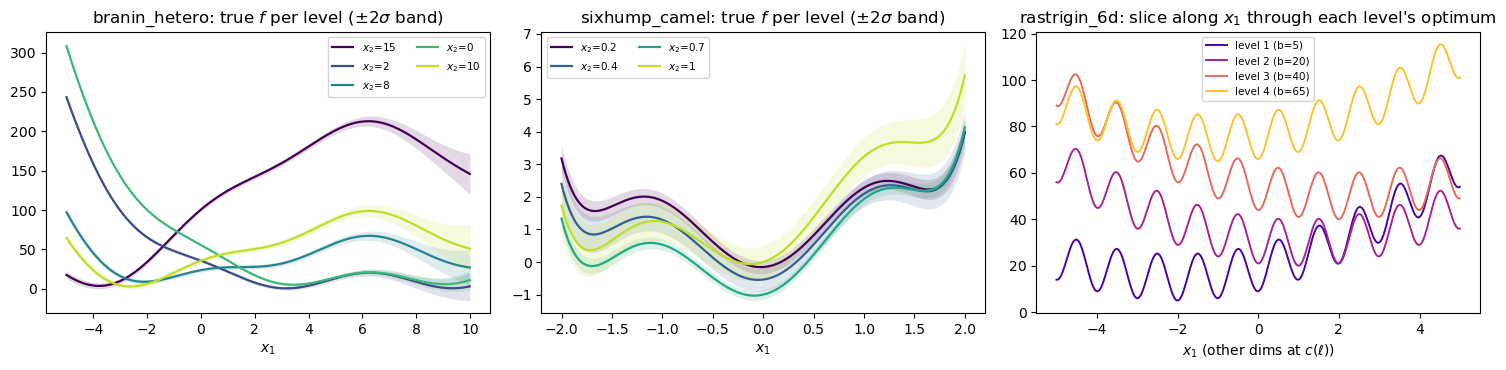

Note the scale contrast: branin levels are separated by O(100) y-units, camel levels by O(1) — with edge noise of the same order. Level discrimination is trivial on branin, hard on camel.


In [3]:
# True surfaces (band = +/- 2 sigma noise) for the three problems
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
cmap1 = plt.cm.viridis(np.linspace(0, .9, spec1.n_levels))
cmapC = plt.cm.viridis(np.linspace(0, .9, specC.n_levels))
for spec, cm, ax in [(spec1, cmap1, axes[0]), (specC, cmapC, axes[1])]:
    xs = np.linspace(spec.lb, spec.ub, 400)
    for lv in spec.levels:
        f = spec.f_true_level(xs, lv); sg = spec.sigma_level(xs, lv)
        ax.plot(xs, f, color=cm[lv-1], lw=1.6, label=f"$x_2$={spec.meta['cat_values'][lv-1]:g}")
        ax.fill_between(xs, f-2*sg, f+2*sg, color=cm[lv-1], alpha=.15, lw=0)
    ax.set(title=f"{spec.name}: true $f$ per level ($\\pm2\\sigma$ band)", xlabel="$x_1$")
    ax.legend(fontsize=7.5, ncol=2)
ts = np.linspace(-5, 5, 400)
for lv in spec6.levels:
    c = np.asarray(spec6.meta["centers"][lv-1])
    Xs = np.tile(c, (len(ts), 1)); Xs[:, 0] = ts
    axes[2].plot(ts, spec6.f_true_level(Xs, lv), color=plt.cm.plasma(.12+.25*(lv-1)), lw=1.4,
                 label=f"level {lv} (b={spec6.meta['b_shift'][lv-1]:g})")
axes[2].set(title="rastrigin_6d: slice along $x_1$ through each level's optimum",
            xlabel="$x_1$ (other dims at $c(\\ell)$)"); axes[2].legend(fontsize=7.5)
plt.tight_layout(); plt.show()
print("Note the scale contrast: branin levels are separated by O(100) y-units, camel levels by O(1)"
      " — with edge noise of the same order. Level discrimination is trivial on branin, hard on camel.")

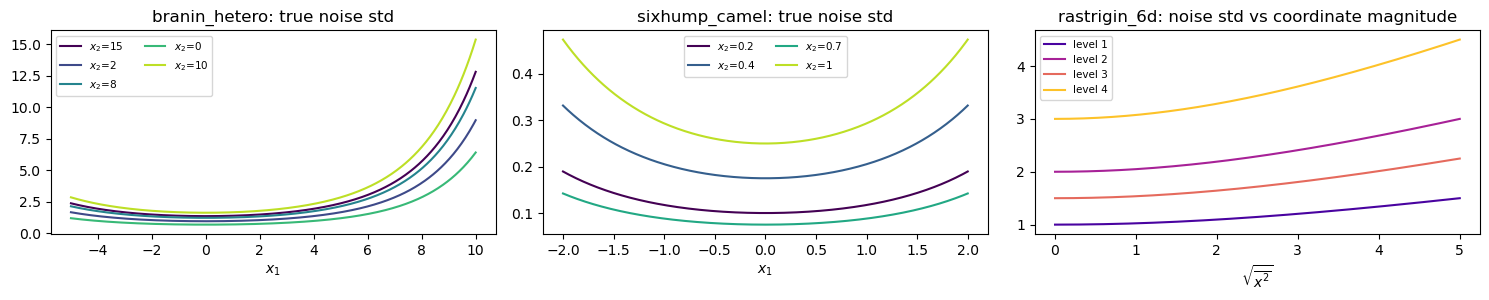

In [4]:
# Noise structure sigma(x, level)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.1))
for spec, cm, ax in [(spec1, cmap1, axes[0]), (specC, cmapC, axes[1])]:
    xs = np.linspace(spec.lb, spec.ub, 400)
    for lv in spec.levels:
        ax.plot(xs, spec.sigma_level(xs, lv), color=cm[lv-1], lw=1.5,
                label=f"$x_2$={spec.meta['cat_values'][lv-1]:g}")
    ax.set(title=f"{spec.name}: true noise std", xlabel="$x_1$"); ax.legend(fontsize=7.5, ncol=2)
rr = np.linspace(0, 5, 200)
for lv in spec6.levels:
    axes[2].plot(rr, np.sqrt(1+0.05*rr**2)*spec6.meta["noise_muls"][lv-1],
                 color=plt.cm.plasma(.12+.25*(lv-1)), lw=1.5, label=f"level {lv}")
axes[2].set(title="rastrigin_6d: noise std vs coordinate magnitude",
            xlabel=r"$\sqrt{\overline{x^2}}$"); axes[2].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

### Problem overview — true response, noise band & design

One figure per problem: **left** — true $f$ per level with the $\pm2\sigma$ noise band and the
SLHD design (large dots = replicate means, faint dots = the individual replicates); **right** —
the true noise std per level. For `rastrigin_6d` the panels show the 1-D slice along $x_1$
through level 1's center $\mathbf{c}(1)$ (the 5-D design points live off this slice, so they
are not drawn).

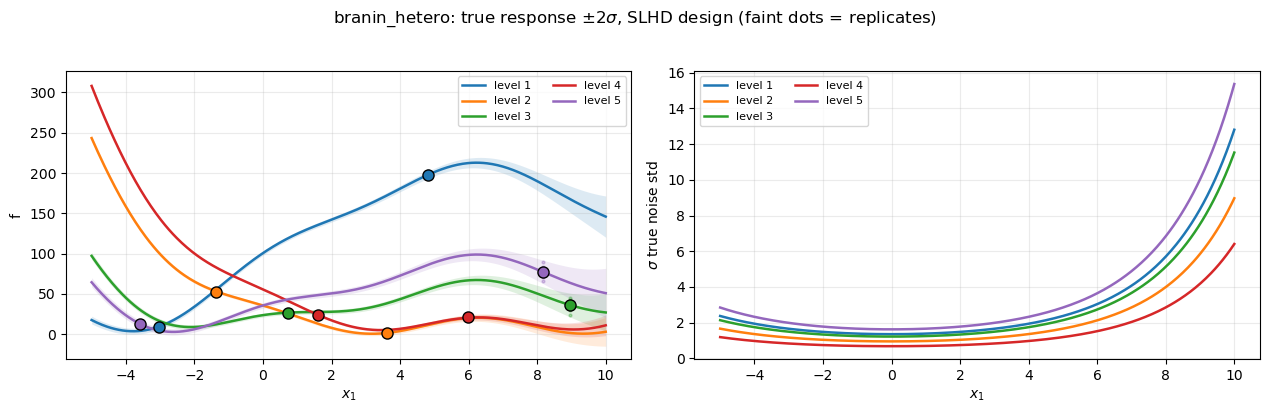

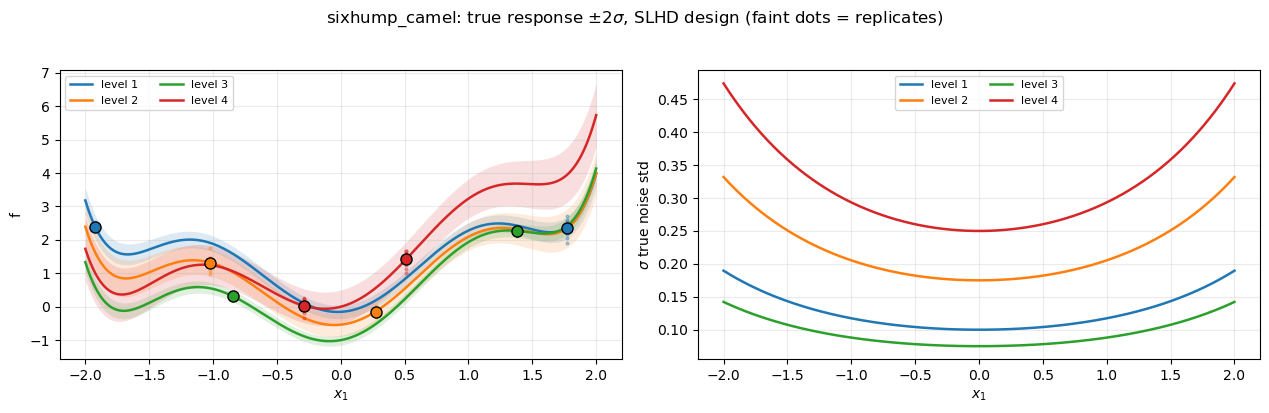

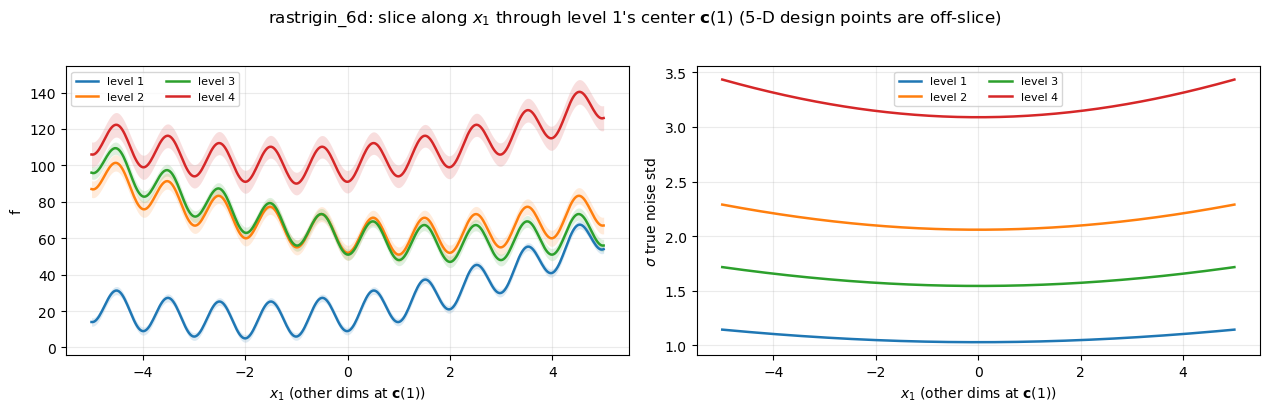

In [5]:
def overview_1d(problem):
    spec = P.get(problem)
    ds = doe_cache.load(problem, SEED, N_REP)
    xs = np.linspace(spec.lb, spec.ub, 400)
    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4))
    for lv in spec.levels:
        f = spec.f_true_level(xs, lv); sg = spec.sigma_level(xs, lv)
        axes[0].plot(xs, f, color=f"C{lv-1}", lw=1.8, label=f"level {lv}")
        axes[0].fill_between(xs, f-2*sg, f+2*sg, color=f"C{lv-1}", alpha=.15, lw=0)
        axes[1].plot(xs, sg, color=f"C{lv-1}", lw=1.8, label=f"level {lv}")
    X = ds["X_sample"]; lvc = X[:, spec.d].astype(int)
    for i in range(len(X)):
        c = f"C{lvc[i]-1}"
        axes[0].plot([X[i, 0]]*ds["Y_rep"].shape[1], ds["Y_rep"][i], ".", color=c, ms=4,
                     alpha=.35, zorder=4)
        axes[0].plot(X[i, 0], ds["Y_sample"][i], "o", color=c, mec="k", ms=8, zorder=5)
    axes[0].set(xlabel="$x_1$", ylabel="f"); axes[1].set(xlabel="$x_1$",
                                                         ylabel="$\sigma$ true noise std")
    for ax in axes: ax.legend(fontsize=8, ncol=2); ax.grid(alpha=.25)
    fig.suptitle(f"{spec.name}: true response $\pm2\sigma$, SLHD design "
                 f"(faint dots = replicates)", y=1.02)
    plt.tight_layout(); plt.show()

overview_1d("branin_hetero")
overview_1d("sixhump_camel")

# rastrigin_6d: slice along x1 through level 1's center c(1)
spec = P.get("rastrigin_6d")
c1 = np.asarray(spec.meta["centers"][0], float)
ts = np.linspace(-5, 5, 400)
XS = np.tile(c1, (len(ts), 1)); XS[:, 0] = ts
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4))
for lv in spec.levels:
    f = spec.f_true_level(XS, lv); sg = spec.sigma_level(XS, lv)
    axes[0].plot(ts, f, color=f"C{lv-1}", lw=1.8, label=f"level {lv}")
    axes[0].fill_between(ts, f-2*sg, f+2*sg, color=f"C{lv-1}", alpha=.15, lw=0)
    axes[1].plot(ts, sg, color=f"C{lv-1}", lw=1.8, label=f"level {lv}")
axes[0].set(xlabel="$x_1$ (other dims at $\mathbf{c}(1)$)", ylabel="f")
axes[1].set(xlabel="$x_1$ (other dims at $\mathbf{c}(1)$)", ylabel="$\sigma$ true noise std")
for ax in axes: ax.legend(fontsize=8, ncol=2); ax.grid(alpha=.25)
fig.suptitle("rastrigin_6d: slice along $x_1$ through level 1's center $\mathbf{c}(1)$ "
             "(5-D design points are off-slice)", y=1.02)
plt.tight_layout(); plt.show()

---
## 2&nbsp;&nbsp;Design of experiments (DOE)

**Sliced Latin Hypercube Design (SLHD) with replicates**, from `utils/doe.py` / `utils/doe_cache.py`:

* Each level's design points form an LHS over the full continuous domain **and** the union across
  levels is itself a full LHS — balanced per level *and* space-filling overall (the recommended
  design for LVGPs, which pool information across levels).
* Every design point is evaluated with **n_rep noisy replicates**
  $y_j = f(\mathbf{x},\ell)+\varepsilon_j$, $\varepsilon_j\sim\mathcal N(0,\sigma^2(\mathbf{x},\ell))$.
  Models train on the replicate **mean** and receive the replicate **variance** (ddof = 1) as the
  noise estimate — this is what the heteroscedastic models consume. We run the whole grid at
  **n_rep = 3 and n_rep = 10** (section 8 compares them). The variance estimate from $k$
  replicates has relative std $\sqrt{2/(k-1)}$ — **100% at n_rep = 3 vs 47% at n_rep = 10** —
  so the replicate axis directly probes how much a heteroscedastic model suffers when its noise
  information is nearly worthless.
* Designs are **deterministic per (problem, seed, n_rep, n_init)** and cached as `.mat` files that
  both engines read, so all four models see the *byte-identical* dataset (common random numbers):
  any metric difference is purely a model difference, never a data difference.

Budgets — **three per problem**, because model ranking turns out to depend strongly on the
regime: the canonical BO-style budget of 2 points/level (branin: 10, camel: 8), a **middle
budget of ~5 points/level** (branin: 25, camel: 20, rastrigin: 20), and a moderate modeling
budget of 8 points/level (branin: 40, camel: 32, rastrigin: 32 — the rastrigin default).

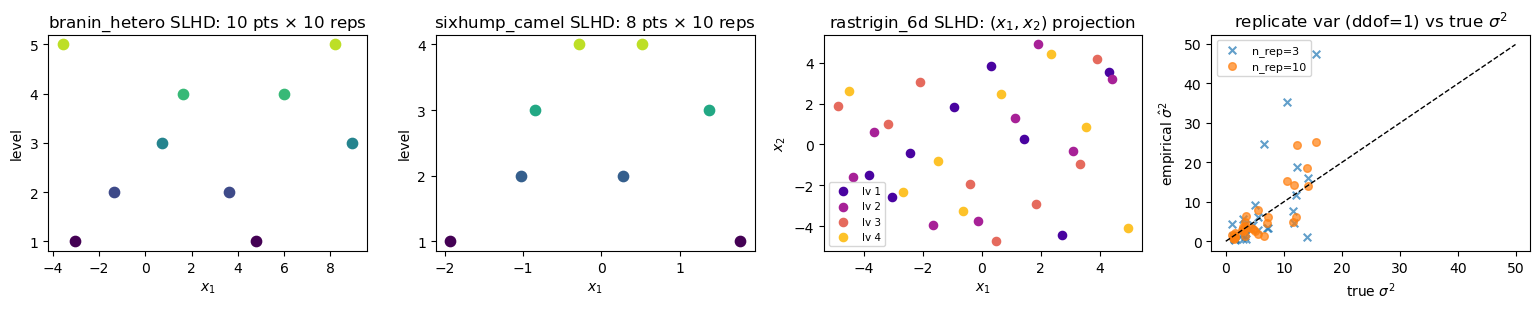

The empirical variances scatter around truth — badly at n_rep=3 (relative std ~100%) and noticeably even at n_rep=10 (~47%). This is the realistic noise information the heteroscedastic models actually receive.


In [6]:
ds1 = doe_cache.load("branin_hetero", SEED, N_REP)
dsC = doe_cache.load("sixhump_camel", SEED, N_REP)
ds6 = doe_cache.load("rastrigin_6d", SEED, N_REP)

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.2))
for ax, (spec, ds) in zip(axes[:2], [(spec1, ds1), (specC, dsC)]):
    X = ds["X_sample"]
    for lv in spec.levels:
        m = X[:, 1].astype(int) == lv
        ax.scatter(X[m, 0], [lv]*m.sum(), s=55,
                   color=plt.cm.viridis(.9*(lv-1)/(spec.n_levels-1)), zorder=3)
    ax.set(title=f"{spec.name} SLHD: {len(X)} pts $\\times$ {N_REP} reps",
           xlabel="$x_1$", ylabel="level", yticks=spec.levels)
X6 = ds6["X_sample"]; lv6 = X6[:, 5].astype(int)
for lv in spec6.levels:
    m = lv6 == lv
    axes[2].scatter(X6[m, 0], X6[m, 1], s=35, color=plt.cm.plasma(.12+.25*(lv-1)), label=f"lv {lv}")
axes[2].set(title="rastrigin_6d SLHD: $(x_1,x_2)$ projection", xlabel="$x_1$", ylabel="$x_2$")
axes[2].legend(fontsize=7.5)
ds6_3 = doe_cache.load("rastrigin_6d", SEED, 3)
for ds_, mk, lab in [(ds6_3, "x", "n_rep=3"), (ds6, "o", "n_rep=10")]:
    Xa = ds_["X_sample"]; la = Xa[:, 5].astype(int)
    tv = np.concatenate([spec6.sigma_level(Xa[la == lv, :5], lv)**2 for lv in spec6.levels])
    ev = np.concatenate([ds_["Var_sample"][la == lv] for lv in spec6.levels])
    axes[3].scatter(tv, ev, s=30, marker=mk, alpha=.7, label=lab)
lims = [0, max(ds6["Var_sample"].max(), ds6_3["Var_sample"].max())*1.05]
axes[3].plot(lims, lims, "k--", lw=1); axes[3].legend(fontsize=8)
axes[3].set(title="replicate var (ddof=1) vs true $\\sigma^2$",
            xlabel="true $\\sigma^2$", ylabel="empirical $\\hat\\sigma^2$")
plt.tight_layout(); plt.show()
print("The empirical variances scatter around truth — badly at n_rep=3 (relative std ~100%) and"
      " noticeably even at n_rep=10 (~47%). This is the realistic noise information the"
      " heteroscedastic models actually receive.")

---
## 3&nbsp;&nbsp;Metrics

Evaluated on a **held-out ground-truth test set** (never on training points): a dense grid of 200
points per level for the 1-D problems; the same scrambled-Sobol cloud of 1024 points in $[-5,5]^5$
for every level of `rastrigin_6d`. With truth $f_i$, posterior mean $\mu_i$ and predictive
(epistemic) std $s_i$, and $z=1.645$ (90% two-sided interval $[L_i,U_i]=\mu_i\mp z s_i$):

| metric | definition | reads as | target |
|--------|------------|----------|--------|
| **MAE** | $\frac1n\sum\lvert\mu_i-f_i\rvert$ | surface accuracy in raw $y$ units | low |
| **RRMSE** | $\sqrt{\frac1n\sum(\mu_i-f_i)^2}\,/\,\mathrm{std}(f)$ | relative accuracy (≈1 ⇒ no better than predicting the level mean) | low |
| **IS** | $\frac1n\sum\big[(U_i-L_i)+\frac2{0.1}(L_i-f_i)_+ +\frac2{0.1}(f_i-U_i)_+\big]$ | Gneiting–Raftery 90% interval score: interval width **plus** 20× the miss distance — accuracy *and* calibration in one proper score | low |
| **Coverage** | $\frac1n\sum \mathbf 1\{\lvert\mu_i-f_i\rvert\le z\,s_i\}$ | fraction of truth inside the 90% CI | **≈ 0.90** (higher is *not* better: ≫0.9 = under-confident, ≪0.9 = over-confident) |

Tables report each metric **per categorical level** (rows) and the **mean over levels** — the same
layout as the study's summary figure.

---
## 4&nbsp;&nbsp;Fit the four models

Each model is fit on the identical per-level dataset `{X, y_mean, y_var}` and asked for
$(\mu, s^2)$ on the fixed test set. The MATLAB LVGPs run the postdoc's `LVGP_fit` /
`LVGP_fit_noise` unmodified via the bridge; results are cached in `results/pred_cache/`.

In [7]:
def all_tables(problem, n_init=None, seed=SEED):
    spec = P.get(problem); Xt = study.test_points(spec)
    return {LABELS[k]: MET.metrics_table(
                spec, study.CachedPredictions(problem, k, seed, N_REP, n_init), Xt)
            for k in MODEL_KEYS}

def show_combined(tabs, title):
    big = MET.combined_table(tabs)
    def _hl(df):
        sty = pd.DataFrame("", index=df.index, columns=df.columns)
        for met in ["MAE", "RRMSE", "IS", "Coverage"]:
            sub = df.xs(met, axis=1, level=1)
            for row in df.index:
                v = sub.loc[row]
                best = (v - .90).abs().idxmin() if met == "Coverage" else v.idxmin()
                sty.loc[row, (best, met)] = "font-weight: bold; background-color: #eaf5ee"
        return sty
    return (big.style.apply(_hl, axis=None).format("{:.4f}")
            .set_caption(title).set_table_styles(
                [{"selector": "caption", "props": "font-size:1.05em; font-weight:bold; padding:6px"}]))

def show_rank(tabs, title):
    return MET.rank_summary(tabs).style.format("{:.4f}",
        subset=pd.IndexSlice[list(tabs), :]).set_caption(title)

def plot_1d_fits(problem, n_init, tag):
    spec = P.get(problem)
    Xt = study.test_points(spec)[1]
    dsn = doe_cache.load(problem, SEED, N_REP, n_init=n_init)
    fig, axes = plt.subplots(len(MODEL_KEYS), spec.n_levels,
                             figsize=(2.9*spec.n_levels, 2.4*len(MODEL_KEYS)),
                             sharex=True, squeeze=False)
    for i, k in enumerate(MODEL_KEYS):
        mdl = study.CachedPredictions(problem, k, SEED, N_REP, n_init)
        for j, lv in enumerate(spec.levels):
            ax = axes[i, j]
            ft = np.ravel(spec.f_true_level(Xt, lv))
            mu, s = mdl.mean_std(lv, Xt)
            ax.plot(Xt.ravel(), ft, "k-", lw=1.1)
            ax.plot(Xt.ravel(), mu, color=COLORS[k], lw=1.4)
            ax.fill_between(Xt.ravel(), mu-1.645*s, mu+1.645*s, color=COLORS[k], alpha=.25, lw=0)
            m = dsn["X_sample"][:, 1].astype(int) == lv
            ax.plot(dsn["X_sample"][m, 0], dsn["Y_sample"][m], "r.", ms=8, zorder=5)
            if i == 0: ax.set_title(f"$x_2$={spec.meta['cat_values'][lv-1]:g}", fontsize=10)
            if j == 0: ax.set_ylabel(LABELS[k], fontsize=9)
    fig.suptitle(f"{problem}, {tag}: truth (black), mean ± 90% CI (color), training means (red)",
                 y=1.005, fontsize=11)
    plt.tight_layout(); plt.show()

tabs1_10 = all_tables("branin_hetero")                 # n = 10 (2/level)
tabs1_25 = all_tables("branin_hetero", n_init=NMID_B)  # n = 25 (5/level)
tabs1_40 = all_tables("branin_hetero", n_init=N40)     # n = 40 (8/level)
tabsC_8  = all_tables("sixhump_camel")                 # n = 8  (2/level)
tabsC_20 = all_tables("sixhump_camel", n_init=NMID_C)  # n = 20 (5/level)
tabsC_32 = all_tables("sixhump_camel", n_init=NBIG)    # n = 32 (8/level)
tabs6_20 = all_tables("rastrigin_6d", n_init=NMID_R)   # n = 20 (5/level)
tabs6    = all_tables("rastrigin_6d")                  # n = 32 (8/level)
tabs6_80 = all_tables("rastrigin_6d", n_init=NR80)     # n = 80 (20/level)
tabs6_160 = all_tables("rastrigin_6d", n_init=NR160)   # n = 160 (40/level)
print("all four models loaded/fit for all problems (cache: results/pred_cache/)")

all four models loaded/fit for all problems (cache: results/pred_cache/)


---
## 5&nbsp;&nbsp;Results — `branin_hetero` (1-D, 5 levels)

Per-level tables (best value per metric-column across models highlighted; Coverage judged by
closeness to 0.90). Three training budgets: **§5.1 n = 10** (2 pts/level, data-starved),
**§5.2 n = 25** (5 pts/level, middle) and **§5.3 n = 40** (8 pts/level, moderate).

In [8]:
show_combined(tabs1_10, f"branin_hetero, n_train = 10 (2/level) — per-level metrics "
                        f"(seed {SEED}, n_rep {N_REP}; test: 200-pt grid/level)")

In [9]:
show_rank(tabs1_10, "branin_hetero (n=10) — mean over levels + best model per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,26.1693,0.8475,360.2642,0.6680
Categorical GP,24.5372,0.7582,173.5468,0.9420
Standard LVGP,24.7147,0.8273,332.5801,0.3300
H-LVGP,43.3687,1.6631,589.7470,0.3540
,Categorical GP,Categorical GP,Categorical GP,Categorical GP


### 5.2&nbsp; n = 25 (5 points per level)

In [10]:
show_combined(tabs1_25, f"branin_hetero, n_train = 25 (5/level) — per-level metrics "
                        f"(seed {SEED}, n_rep {N_REP}; test: 200-pt grid/level)")

In [11]:
show_rank(tabs1_25, "branin_hetero (n=25) — mean over levels + best model per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,9.5906,0.3852,69.3104,0.6860
Categorical GP,3.5821,0.1369,23.5704,0.8300
Standard LVGP,2.5532,0.1385,19.1814,0.3840
H-LVGP,2.0942,0.0899,11.2857,0.9920
,H-LVGP,H-LVGP,H-LVGP,Categorical GP


### 5.3&nbsp; n = 40 (8 points per level)

In [12]:
show_combined(tabs1_40, f"branin_hetero, n_train = 40 (8/level) — per-level metrics "
                        f"(seed {SEED}, n_rep {N_REP}; test: 200-pt grid/level)")

In [13]:
show_rank(tabs1_40, "branin_hetero (n=40) — mean over levels + best model per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,2.9798,0.1586,23.3186,0.8850
Categorical GP,0.8582,0.0338,6.2844,1.0000
Standard LVGP,1.8801,0.0736,19.8817,0.1150
H-LVGP,0.6627,0.0271,9.3482,1.0000
,H-LVGP,H-LVGP,Categorical GP,Separate GPs


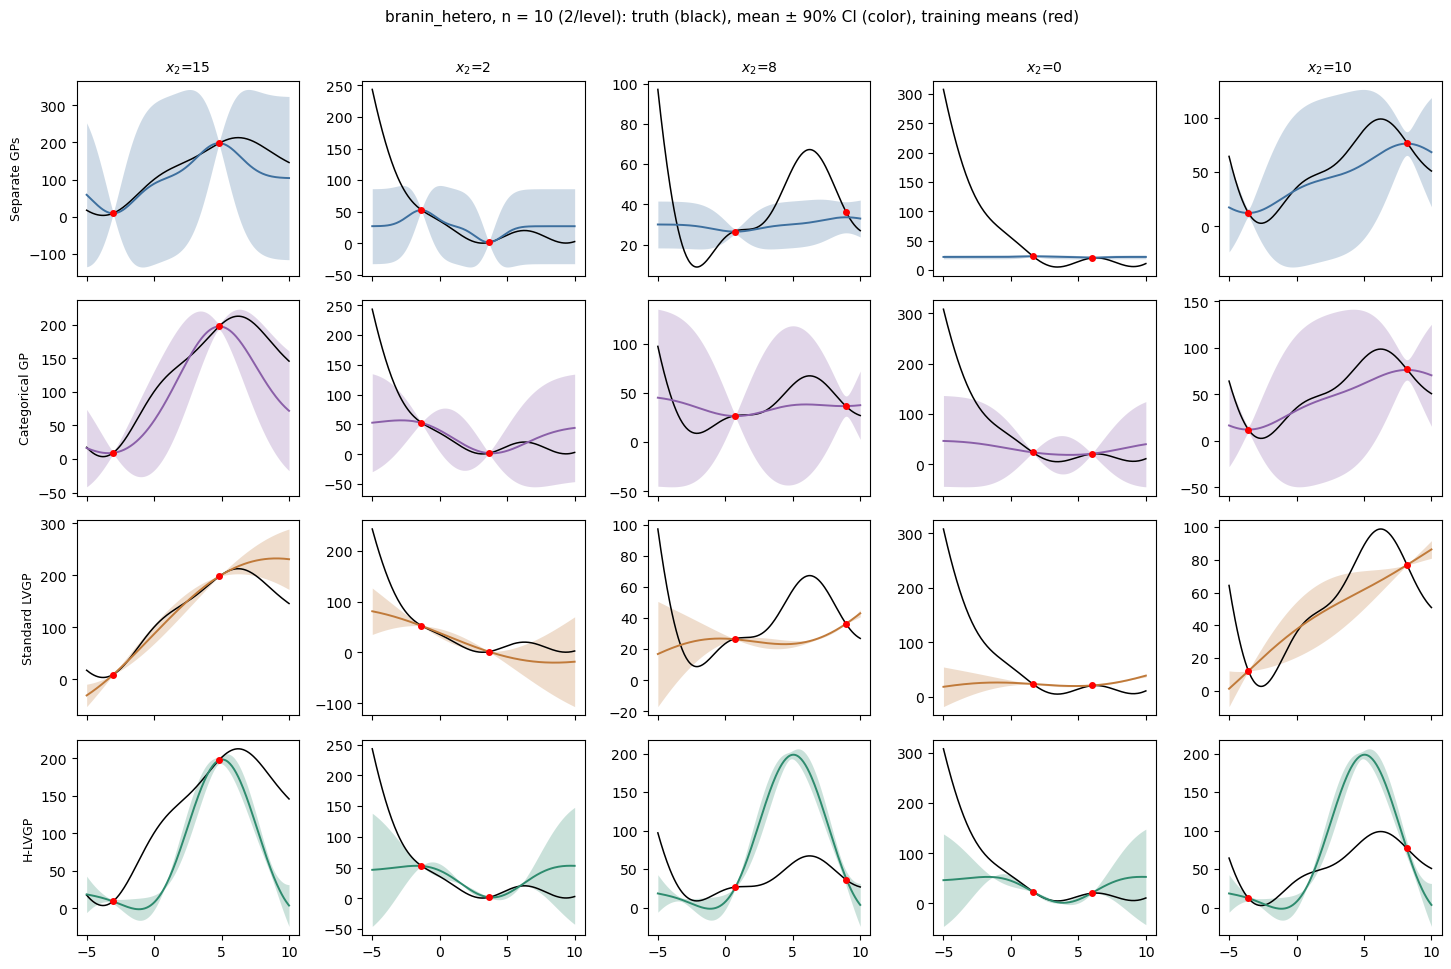

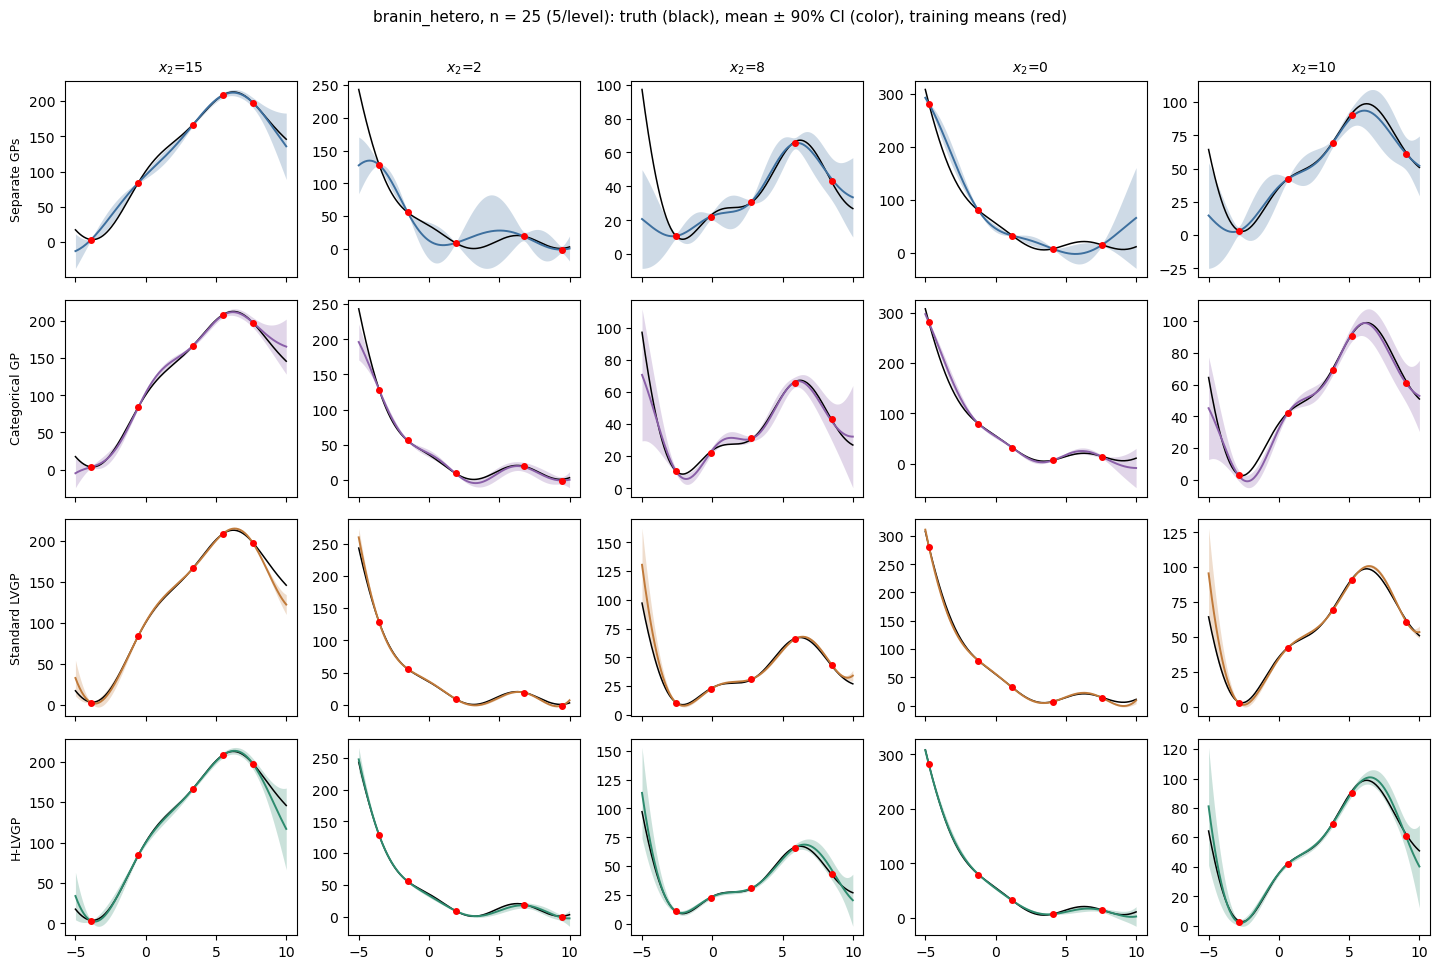

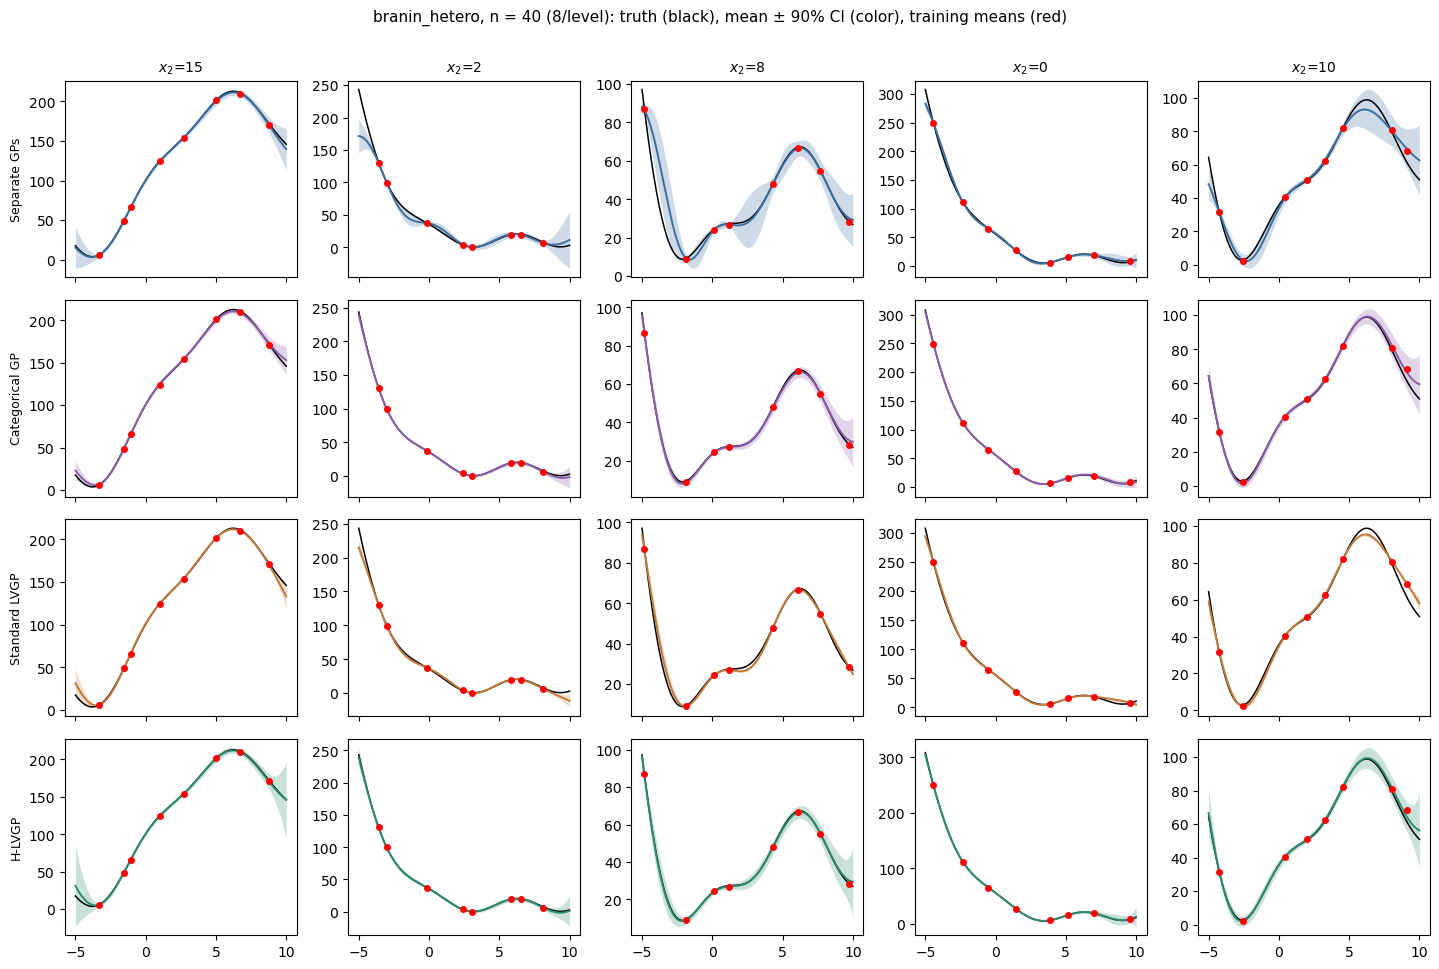

In [14]:
plot_1d_fits("branin_hetero", None, "n = 10 (2/level)")
plot_1d_fits("branin_hetero", NMID_B, "n = 25 (5/level)")
plot_1d_fits("branin_hetero", N40, "n = 40 (8/level)")

**Reading the 1-D picture.** With only 2 training points per level, the *Separate GPs* cannot
see each level's curvature — they revert toward flat means with intervals that are simultaneously
wide and wrong. The three cross-level models share the Branin shape across levels; the LVGPs
additionally place the 5 levels in a learned latent space, so a level's curve is interpolated from
its neighbours — but the latent geometry itself needs data to find, which is why the LVGPs only
show their advantage at the larger budget. The standard LVGP's intervals ignore the (large,
$x$-growing) noise — watch its Coverage; H-LVGP folds the replicate variances into the fit.

---
## 6&nbsp;&nbsp;Results — `sixhump_camel` (1-D, 4 closely-spaced levels)

Same layout: **§6.1 n = 8** (2 pts/level), **§6.2 n = 20** (5 pts/level) and
**§6.3 n = 32** (8 pts/level).

In [15]:
show_combined(tabsC_8, f"sixhump_camel, n_train = 8 (2/level) — per-level metrics "
                        f"(seed {SEED}, n_rep {N_REP}; test: 200-pt grid/level)")

In [16]:
show_rank(tabsC_8, "sixhump_camel (n=8) — mean over levels + best model per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,0.9429,1.1218,9.2211,0.6462
Categorical GP,0.5557,0.6229,3.8902,0.7225
Standard LVGP,0.6343,0.7084,8.2163,0.2200
H-LVGP,0.6319,0.7042,7.0136,0.4187
,Categorical GP,Categorical GP,Categorical GP,Categorical GP


### 6.2&nbsp; n = 20 (5 points per level)

In [17]:
show_combined(tabsC_20, f"sixhump_camel, n_train = 20 (5/level) — per-level metrics "
                        f"(seed {SEED}, n_rep {N_REP}; test: 200-pt grid/level)")

In [18]:
show_rank(tabsC_20, "sixhump_camel (n=20) — mean over levels + best model per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,0.2411,0.3526,1.5244,0.9550
Categorical GP,0.1640,0.2511,1.1175,0.8525
Standard LVGP,0.2097,0.3159,2.3317,0.2725
H-LVGP,0.1821,0.2838,1.1401,0.9187
,Categorical GP,Categorical GP,Categorical GP,H-LVGP


### 6.3&nbsp; n = 32 (8 points per level)

In [19]:
show_combined(tabsC_32, f"sixhump_camel, n_train = 32 (8/level) — per-level metrics "
                        f"(seed {SEED}, n_rep {N_REP}; test: 200-pt grid/level)")

In [20]:
show_rank(tabsC_32, "sixhump_camel (n=32) — mean over levels + best model per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,0.1883,0.3305,1.6362,0.8600
Categorical GP,0.0845,0.1288,0.5680,0.9287
Standard LVGP,0.1400,0.2662,1.6747,0.3425
H-LVGP,0.1073,0.2081,0.6652,0.9938
,Categorical GP,Categorical GP,Categorical GP,Categorical GP


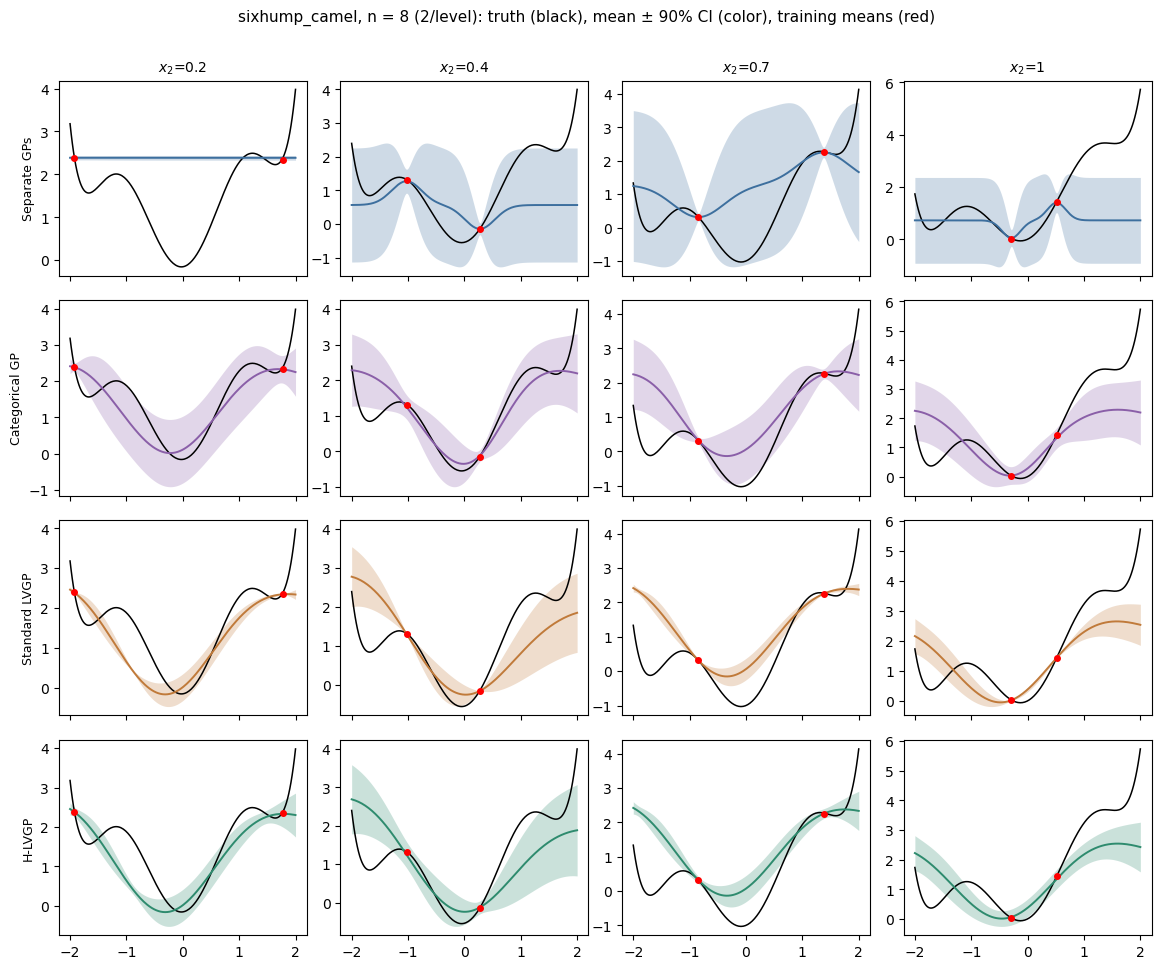

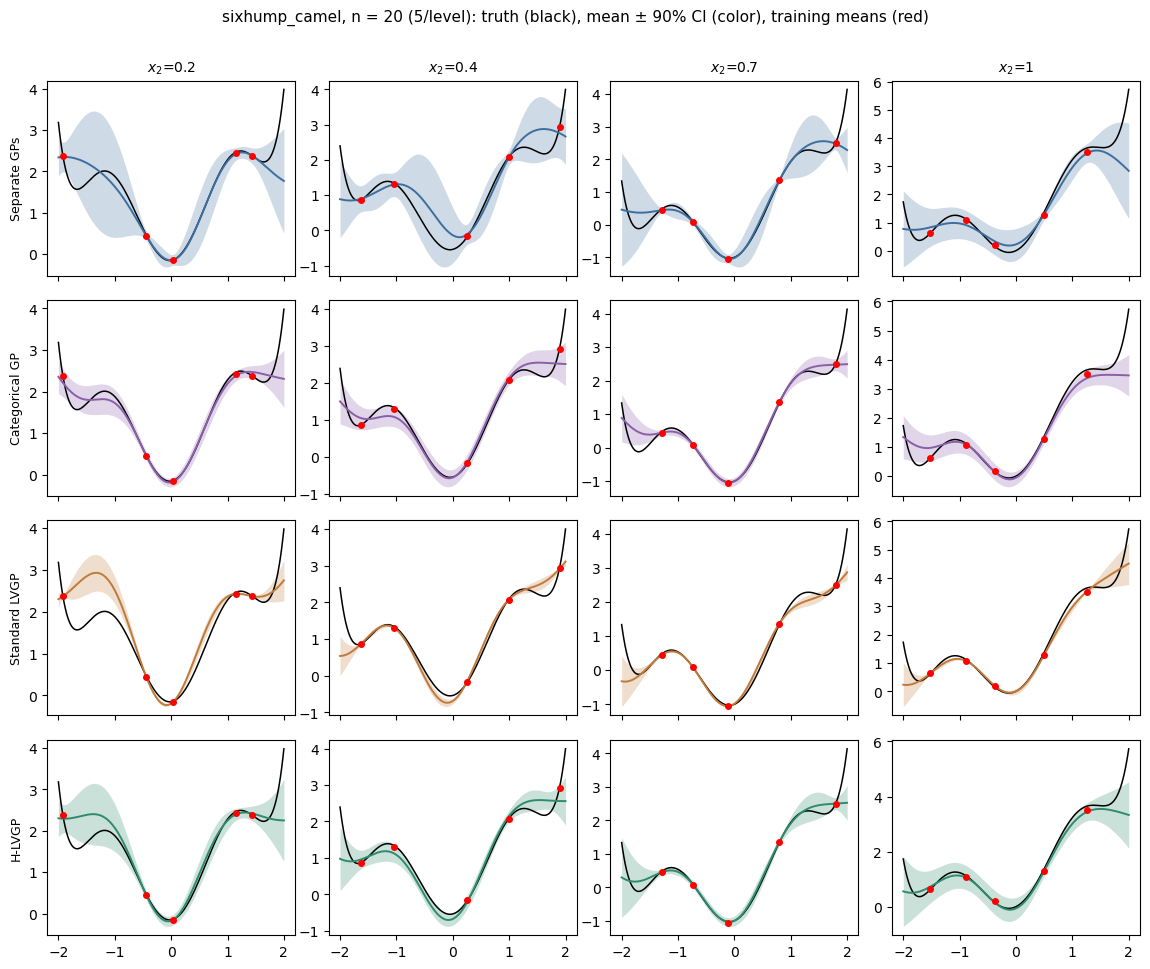

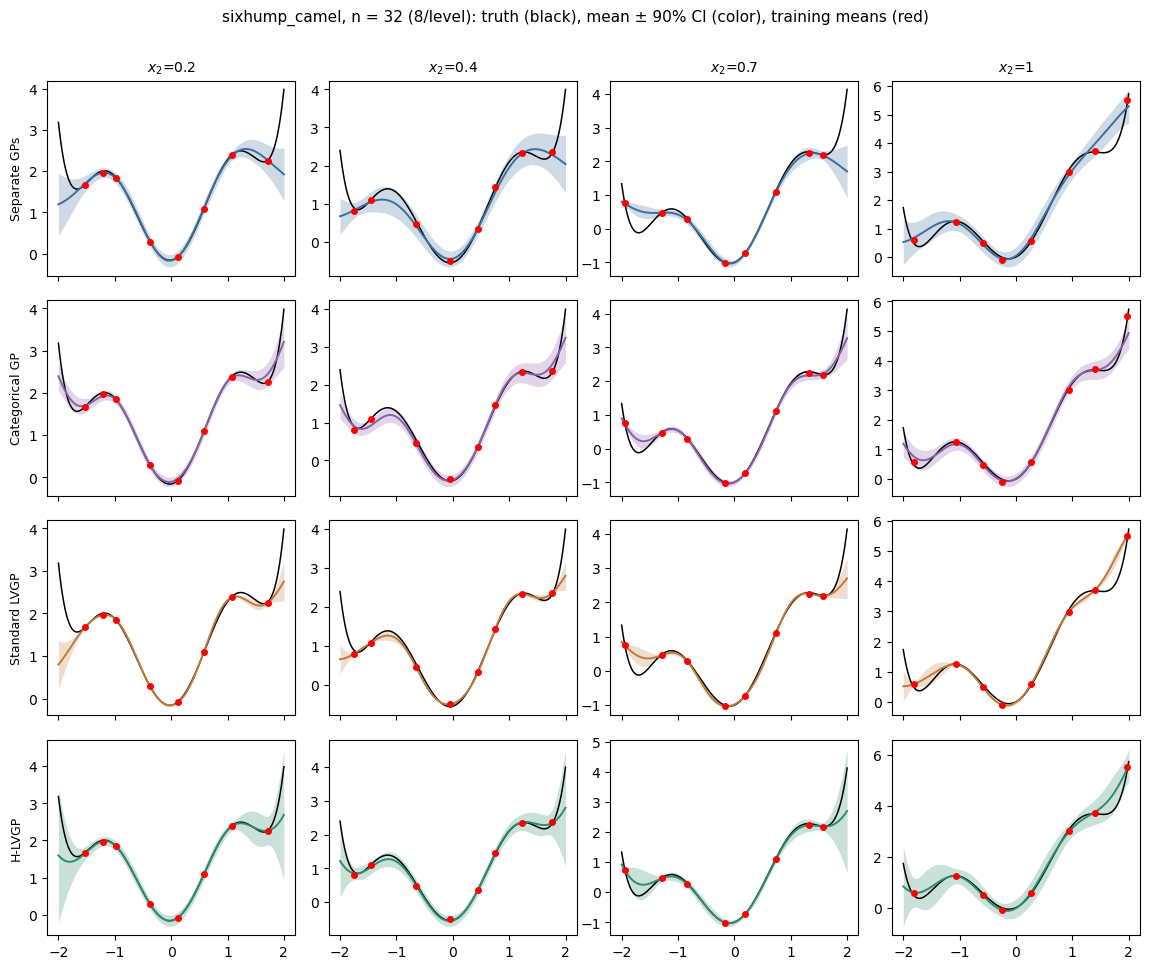

In [21]:
plot_1d_fits("sixhump_camel", None, "n = 8 (2/level)")
plot_1d_fits("sixhump_camel", NMID_C, "n = 20 (5/level)")
plot_1d_fits("sixhump_camel", NBIG, "n = 32 (8/level)")

---
## 7&nbsp;&nbsp;Results — `rastrigin_6d` (5-D + categorical, 4 levels)

Four budgets — the 5-D input space needs far more data than the 1-D problems, so this problem
gets its own larger ladder: **§7.1 n = 20** (5/level), **§7.2 n = 32** (8/level, the BO-study
default), **§7.3 n = 80** (20/level) and **§7.4 n = 160** (40/level).

In [22]:
show_combined(tabs6_20, f"rastrigin_6d, n_train = 20 (5/level) — per-level metrics "
                     f"(seed {SEED}, n_rep {N_REP}; test: 1024 Sobol pts/level)")

In [23]:
show_rank(tabs6_20, "rastrigin_6d (n=20) — mean over levels + best model per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,25.0844,1.0425,168.8003,0.6873
Categorical GP,26.4960,1.1019,203.5404,0.5710
Standard LVGP,30.0056,1.2334,414.1258,0.2427
H-LVGP,29.9145,1.2295,403.0743,0.2583
,Separate GPs,Separate GPs,Separate GPs,Separate GPs


### 7.2&nbsp; n = 32 (8 points per level)

In [24]:
show_combined(tabs6, f"rastrigin_6d — per-level metrics (seed {SEED}, n_rep {N_REP}, "
                     "n_train 32; test: 1024 Sobol pts/level)")

In [25]:
show_rank(tabs6, "rastrigin_6d (n=32) — mean over levels + best model per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,23.1841,0.9554,125.5133,0.8306
Categorical GP,22.8953,0.9405,114.6654,0.8730
Standard LVGP,27.3503,1.1338,255.0651,0.5100
H-LVGP,27.2650,1.1304,249.3798,0.5205
,Categorical GP,Categorical GP,Categorical GP,Categorical GP


### 7.3&nbsp; n = 80 (20 points per level)

In [26]:
show_combined(tabs6_80, f"rastrigin_6d, n_train = 80 (20/level) — per-level metrics "
                     f"(seed {SEED}, n_rep {N_REP}; test: 1024 Sobol pts/level)")

In [27]:
show_rank(tabs6_80, "rastrigin_6d (n=80) — mean over levels + best model per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,19.5795,0.8149,141.0882,0.6479
Categorical GP,19.4679,0.8178,133.7485,0.6729
Standard LVGP,18.6779,0.7784,117.4627,0.7393
H-LVGP,18.4756,0.7700,114.1084,0.7490
,H-LVGP,H-LVGP,H-LVGP,H-LVGP


### 7.4&nbsp; n = 160 (40 points per level)

In [28]:
show_combined(tabs6_160, f"rastrigin_6d, n_train = 160 (40/level) — per-level metrics "
                     f"(seed {SEED}, n_rep {N_REP}; test: 1024 Sobol pts/level)")

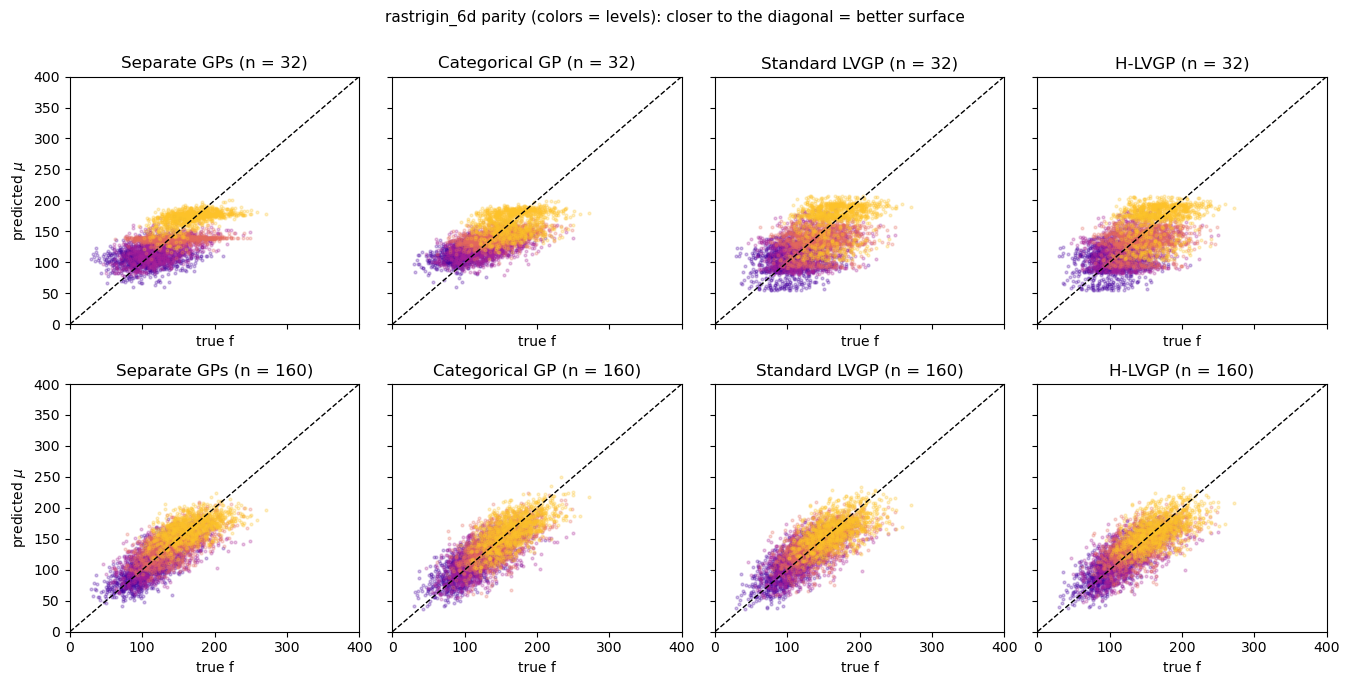

In [29]:
# Parity plots: predicted vs true on the 1024-pt Sobol cloud, all levels pooled
Xt6 = study.test_points(spec6)[1]
fig, axes = plt.subplots(2, len(MODEL_KEYS), figsize=(3.4*len(MODEL_KEYS), 6.8),
                         sharex=True, sharey=True)
for r, (ni, tag) in enumerate([(None, "n = 32"), (NR160, "n = 160")]):
    for ax, k in zip(axes[r], MODEL_KEYS):
        mdl = study.CachedPredictions("rastrigin_6d", k, SEED, N_REP, ni)
        for lv in spec6.levels:
            ft = np.ravel(spec6.f_true_level(Xt6, lv))
            mu, _ = mdl.mean_std(lv, Xt6)
            ax.scatter(ft, mu, s=4, alpha=.25, color=plt.cm.plasma(.12+.25*(lv-1)))
        ax.plot([0, 400], [0, 400], "k--", lw=1)
        ax.set(title=f"{LABELS[k]} ({tag})", xlabel="true f", xlim=(0, 400), ylim=(0, 400))
    axes[r][0].set_ylabel("predicted $\\mu$")
fig.suptitle("rastrigin_6d parity (colors = levels): closer to the diagonal = better surface",
             y=1.0, fontsize=11)
plt.tight_layout(); plt.show()

---
## 8&nbsp;&nbsp;Calibration curves and the replicate axis (n_rep = 3 vs 10)

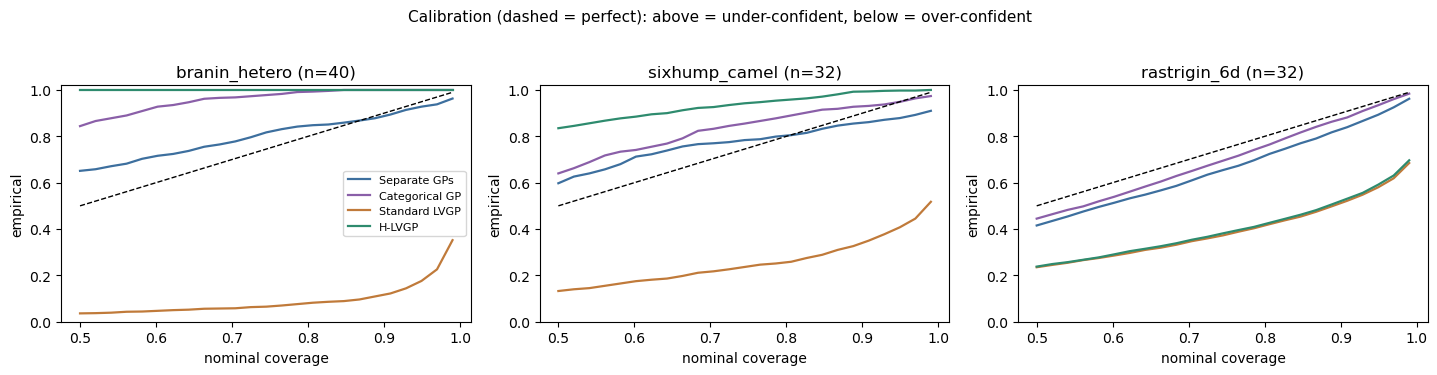

In [30]:
# Calibration: empirical coverage vs nominal, pooled over levels (moderate budgets)
taus = np.linspace(.5, .99, 25)
from scipy.stats import norm
CAL = [("branin_hetero", N40, "branin_hetero (n=40)"),
       ("sixhump_camel", NBIG, "sixhump_camel (n=32)"),
       ("rastrigin_6d", None, "rastrigin_6d (n=32)")]
fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))
for ax, (prob, ni, ttl) in zip(axes, CAL):
    spec = P.get(prob); Xt = study.test_points(spec)
    for k in MODEL_KEYS:
        mdl = study.CachedPredictions(prob, k, SEED, N_REP, ni)
        errs, ss = [], []
        for lv in spec.levels:
            mu, s = mdl.mean_std(lv, Xt[lv])
            errs.append(np.abs(np.ravel(spec.f_true_level(Xt[lv], lv)) - mu)); ss.append(s)
        e, s_ = np.concatenate(errs), np.concatenate(ss)
        cov = [(e <= norm.ppf(.5 + t/2) * s_).mean() for t in taus]
        ax.plot(taus, cov, lw=1.6, color=COLORS[k], label=LABELS[k])
    ax.plot(taus, taus, "k--", lw=1)
    ax.set(title=ttl, xlabel="nominal coverage", ylabel="empirical", ylim=(0, 1.02))
axes[0].legend(fontsize=8)
fig.suptitle("Calibration (dashed = perfect): above = under-confident, below = over-confident",
             y=1.03, fontsize=11)
plt.tight_layout(); plt.show()

**Replicate comparison.** The whole grid is repeated with the SAME design locations but
**n_rep = 3** replicates per location instead of 10 (fixed seed; identical data across models
within an n_rep). Fewer replicates = noisier training means *and* nearly-worthless replicate
variances (relative std ~100%) — the stress test for the heteroscedastic treatments.
Mean-over-levels metrics for every (problem, budget) × model × n_rep:

In [31]:
CONFIGS = [("branin_hetero", None, "branin (n=10)"), ("branin_hetero", NMID_B, "branin (n=25)"),
           ("branin_hetero", N40, "branin (n=40)"),
           ("sixhump_camel", None, "camel (n=8)"), ("sixhump_camel", NMID_C, "camel (n=20)"),
           ("sixhump_camel", NBIG, "camel (n=32)"),
           ("rastrigin_6d", NMID_R, "rastrigin_6d (n=20)"), ("rastrigin_6d", None, "rastrigin_6d (n=32)"),
           ("rastrigin_6d", NR80, "rastrigin_6d (n=80)"), ("rastrigin_6d", NR160, "rastrigin_6d (n=160)")]
rows = []
for prob, ni, tag in CONFIGS:
    spec = P.get(prob); Xt = study.test_points(spec)
    for nr in N_REPS:
        for k in MODEL_KEYS:
            t = MET.metrics_table(spec, study.CachedPredictions(prob, k, SEED, nr, ni), Xt)
            rows.append(dict(problem=tag, n_rep=nr, model=LABELS[k], **t.loc["Mean"].to_dict()))
df = pd.DataFrame(rows)
piv = df.pivot_table(index=["problem", "model"], columns="n_rep",
                     values=["MAE", "RRMSE", "IS", "Coverage"]).round(4)
piv = piv.reindex([c[2] for c in CONFIGS], level=0).reindex(
    [LABELS[k] for k in MODEL_KEYS], level=1)[["MAE", "RRMSE", "IS", "Coverage"]]
piv

MAE          RRMSE              IS  \
n_rep                                    3       10     3      10       3    
problem              model                                                   
branin (n=10)        Separate GPs   26.3328 26.1693 0.8600 0.8475 349.6570   
                     Categorical GP 24.6611 24.5372 0.7623 0.7582 174.3613   
                     Standard LVGP  35.0321 24.7147 1.2803 0.8273 469.0870   
                     H-LVGP         34.9603 43.3687 1.2789 1.6631 447.5436   
branin (n=25)        Separate GPs    9.5944  9.5906 0.3704 0.3852  66.5641   
                     Categorical GP  3.6114  3.5821 0.1288 0.1369  21.7456   
                     Standard LVGP   2.7694  2.5532 0.1641 0.1385  21.3141   
                     H-LVGP          1.9081  2.0942 0.1196 0.0899  13.5473   
branin (n=40)        Separate GPs    3.2013  2.9798 0.1712 0.1586  24.5432   
                     Categorical GP  1.2141  0.8582 0.0535 0.0338   5.8890   
                     Standard LVGP   1.3819  1.8801 0.0627 0.0736  19.1159   
                     H-LVGP          1.3837  0.6627 0.0555 0.0271   8.5834   
camel (n=8)          Separate GPs    0.9168  0.9429 1.0841 1.1218   8.7425   
                     Categorical GP  0.5638  0.5557 0.6158 0.6229   3.3763   
                     Standard LVGP   0.6275  0.6343 0.6984 0.7084   7.4419   
                     H-LVGP          0.6297  0.6319 0.6964 0.7042   6.3413   
camel (n=20)         Separate GPs    0.2487  0.2411 0.3837 0.3526   1.6398   
                     Categorical GP  0.1542  0.1640 0.2473 0.2511   0.9751   
                     Standard LVGP   0.2889  0.2097 0.4643 0.3159   4.0715   
                     H-LVGP          0.2537  0.1821 0.4077 0.2838   2.1907   
camel (n=32)         Separate GPs    0.1984  0.1883 0.3472 0.3305   1.8042   
                     Categorical GP  0.0870  0.0845 0.1212 0.1288   0.5249   
                     Standard LVGP   0.1399  0.1400 0.2376 0.2662   1.7469   
                     H-LVGP          0.0907  0.1073 0.1342 0.2081   0.9590   
rastrigin_6d (n=20)  Separate GPs   25.1853 25.0844 1.0471 1.0425 169.5066   
                     Categorical GP 26.5908 26.4960 1.1069 1.1019 204.5393   
                     Standard LVGP  28.9016 30.0056 1.2035 1.2334 337.2243   
                     H-LVGP         29.9423 29.9145 1.2414 1.2295 367.6812   
rastrigin_6d (n=32)  Separate GPs   23.1397 23.1841 0.9538 0.9554 124.9595   
                     Categorical GP 22.7743 22.8953 0.9357 0.9405 114.6458   
                     Standard LVGP  27.6975 27.3503 1.1505 1.1338 256.1008   
                     H-LVGP         27.5711 27.2650 1.1452 1.1304 249.9733   
rastrigin_6d (n=80)  Separate GPs   19.7318 19.5795 0.8203 0.8149 143.4670   
                     Categorical GP 19.7825 19.4679 0.8300 0.8178 141.4937   
                     Standard LVGP  18.8462 18.6779 0.7858 0.7784 120.8453   
                     H-LVGP         18.6612 18.4756 0.7777 0.7700 117.7109   
rastrigin_6d (n=160) Separate GPs   19.6404 19.0177 0.8195 0.7907 118.8248   
                     Categorical GP 19.4385 19.3292 0.8043 0.7995 114.0157   
                     Standard LVGP  19.7800 19.5448 0.8245 0.8134 115.5928   
                     H-LVGP         19.6461 19.5573 0.8189 0.8154 113.6923   

                                             Coverage         
n_rep                                     10       3      10  
problem              model                                    
branin (n=10)        Separate GPs   360.2642   0.6860 0.6680  
                     Categorical GP 173.5468   0.9420 0.9420  
                     Standard LVGP  332.5801   0.2670 0.3300  
                     H-LVGP         589.7470   0.3460 0.3540  
branin (n=25)        Separate GPs    69.3104   0.6710 0.6860  
                     Categorical GP  23.5704   0.7900 0.8300  
                     Standard LVGP   19.1814   0.4950 0.3840  
                     H-LVGP          11.2857   0.9900 0

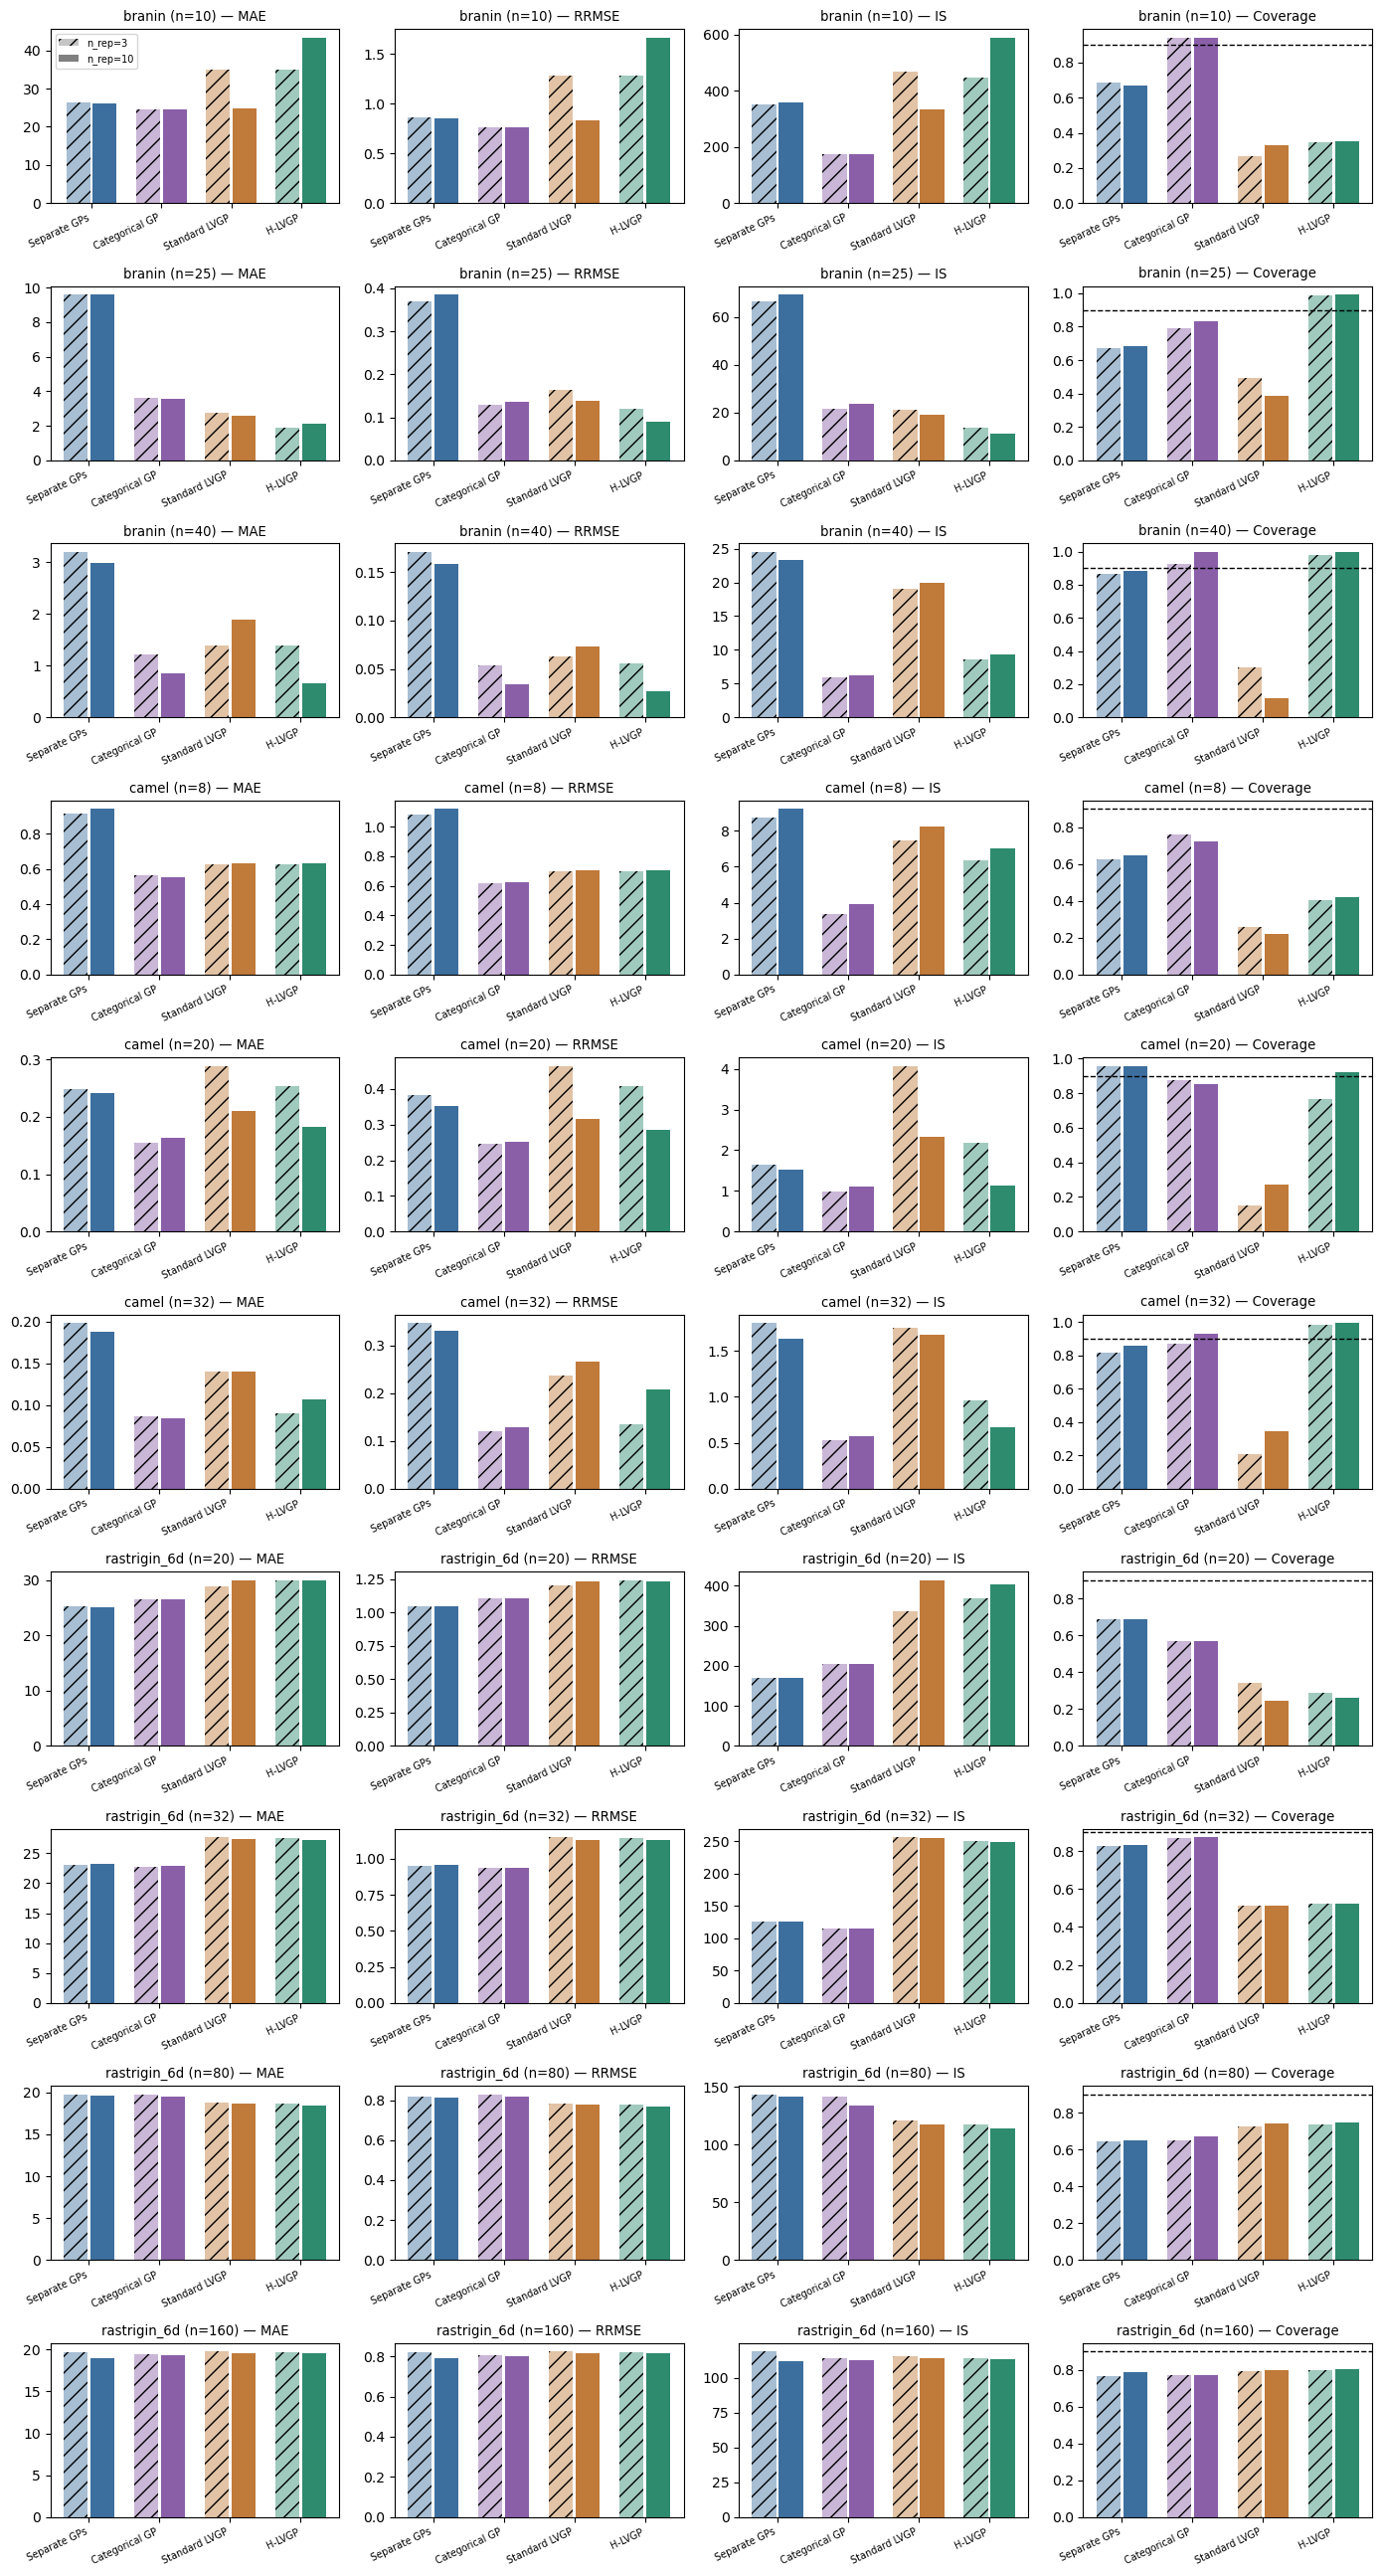

In [32]:
fig, axes = plt.subplots(len(CONFIGS), 4, figsize=(14, 2.6*len(CONFIGS)))
for r, (_, _, tag) in enumerate(CONFIGS):
    for c, met in enumerate(["MAE", "RRMSE", "IS", "Coverage"]):
        ax = axes[r, c]
        for i, k in enumerate(MODEL_KEYS):
            for j, nr in enumerate(N_REPS):
                v = df[(df.problem == tag) & (df.model == LABELS[k])
                       & (df.n_rep == nr)][met].values
                ax.bar(i + (j - .5) * .38, float(v[0]) if len(v) else np.nan, width=.34,
                       color=COLORS[k], alpha=.45 if nr == 3 else 1.0,
                       hatch="//" if nr == 3 else None)
        if met == "Coverage": ax.axhline(.90, color="k", ls="--", lw=1)
        ax.set_xticks(range(4)); ax.set_xticklabels([LABELS[k] for k in MODEL_KEYS],
                                                    rotation=25, ha="right", fontsize=7)
        ax.set_title(f"{tag} — {met}", fontsize=9.5)
axes[0, 0].bar(0, 0, color="gray", alpha=.45, hatch="//", label="n_rep=3")
axes[0, 0].bar(0, 0, color="gray", label="n_rep=10"); axes[0, 0].legend(fontsize=7)
plt.tight_layout(); plt.show()

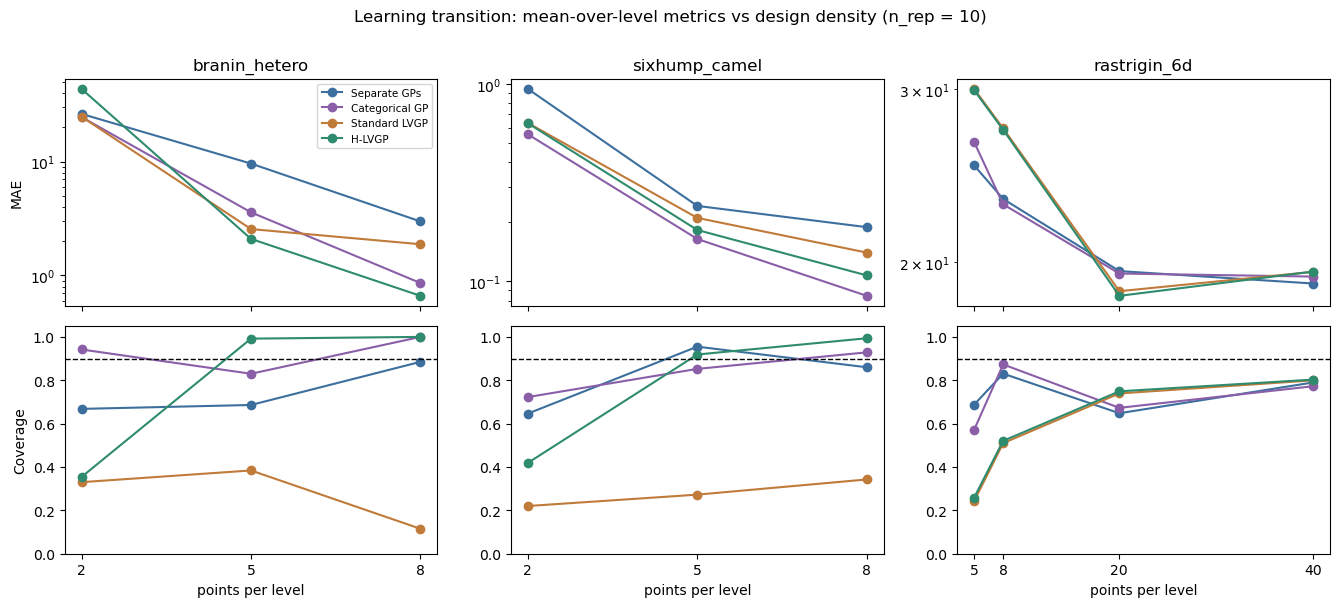

In [33]:
# Budget transition (n_rep = 10): mean metrics vs design density
PROBS = [("branin_hetero", ["branin (n=10)", "branin (n=25)", "branin (n=40)"], [2, 5, 8]),
         ("sixhump_camel", ["camel (n=8)", "camel (n=20)", "camel (n=32)"], [2, 5, 8]),
         ("rastrigin_6d", ["rastrigin_6d (n=20)", "rastrigin_6d (n=32)",
                           "rastrigin_6d (n=80)", "rastrigin_6d (n=160)"], [5, 8, 20, 40])]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 6), sharex="col")
for c, (ttl, tags, ppl) in enumerate(PROBS):
    for r, met in enumerate(["MAE", "Coverage"]):
        ax = axes[r, c]
        for k in MODEL_KEYS:
            v = [df[(df.problem == t) & (df.model == LABELS[k])
                    & (df.n_rep == 10)][met].iloc[0] for t in tags]
            ax.plot(ppl, v, "o-", color=COLORS[k], label=LABELS[k])
        if met == "Coverage":
            ax.axhline(.9, color="k", ls="--", lw=1); ax.set_ylim(0, 1.05)
        else:
            ax.set_yscale("log")
        if r == 0: ax.set_title(ttl)
        if c == 0: ax.set_ylabel(met)
        ax.set_xticks(ppl)
    axes[1, c].set_xlabel("points per level")
axes[0, 0].legend(fontsize=7.5)
fig.suptitle("Learning transition: mean-over-level metrics vs design density (n_rep = 10)", y=1.005)
plt.tight_layout(); plt.show()

---
## 9&nbsp;&nbsp;Conclusions

**1. Cross-level information sharing is the single biggest factor at small budgets.** The
Separate GPs are the weakest model in every data-starved configuration (branin n=10: MAE 26.2,
IS 360; camel n=8: RRMSE 1.12 — *worse than predicting each level's mean*) and still trail by
2–4× MAE at 5 points/level on branin. With so few points per level, a per-level GP cannot see
curvature that the pooled models borrow from the other levels.

**2. Where the models trade places is governed by budget × level structure** (the learning-
transition figure above):

* **branin (well-separated levels with real similarity structure): the H-LVGP takes over already
  at 5 points/level** — n=25: best MAE (2.09 vs CatGP 3.58), best IS (11.3), coverage 0.99 — and
  extends its lead at 8/level (MAE 0.66, RRMSE 0.027). The learned latent recovers the
  {2,4}-vs-{1,3,5} level geometry, and that pays exactly when the levels have structure worth
  recovering. Below the transition (2/level) the same machinery actively hurts (MAE 43).
* **camel (closely-spaced, ordered levels): the Categorical GP keeps the accuracy lead at every
  budget** (n=8: MAE 0.56; n=20: 0.164 vs H-LVGP 0.182; n=32: 0.085 vs 0.107). When the level
  curves nearly overlap there is no geometry for a latent space to exploit — the exchangeable
  level-correlation is the right capacity, while the H-LVGP matches it on IS and is the
  best-calibrated model at the mid budget (coverage 0.92).
* **rastrigin_6d (rugged, level-shifted): the same transition exists but needs ~20 points/level
  in 5-D.** At n=20–32 no model is usable (RRMSE 0.94–1.24) and the ranking even inverts (at
  n=20 the Separate GPs have the best MAE; both LVGPs are worst with coverage ≈ 0.25). At
  **n=80 (20/level) the LVGPs finally take the lead** — H-LVGP best on all four metrics (MAE
  18.5 vs 19.5, IS 114 vs 134–141, coverage 0.75 vs 0.65) — the 5-D analogue of branin's
  5-per-level transition. By **n=160 all four models converge** (MAE 19.0–19.6, RRMSE ≈ 0.80,
  coverage 0.77–0.80): the $\pm10\cos$ ripples are unresolvable at any feasible budget
  (resolving them would need $\sim10^5$ points), so every model plateaus at the smoothed
  quadratic-plus-offset. Beyond ~20/level, extra data buys **calibration** (IS 141 → 112,
  coverage 0.65 → 0.80), not accuracy.

**3. Heteroscedasticity buys calibration, not raw accuracy.** The standard LVGP is severely
overconfident in every configuration where the surface is learnable: coverage 0.12–0.51
against the 0.90 target (branin n=40: 0.115); only on rastrigin at n≥80 — where all models
converge — does it approach the pack (0.74–0.80). Feeding replicate variances into the correlation matrix
(H-LVGP) restores coverage to 0.92–1.00 wherever the surface fit is adequate and roughly halves
the interval score (branin n=25: IS 19.2 → 11.3; camel n=32: 1.67 → 0.67). Mean accuracy is
decided by the level-structure model (point 2), not the noise treatment. This reproduces the
parent repo's headline BO finding on ground-truth metrics.

**4. The replicate axis (n_rep = 3 vs 10) mostly stresses the LVGPs at mid budgets.** The python
models and all noise-blind means barely move. The H-LVGP's calibration survives n_rep = 3 on
branin (coverage 0.99 at both mid and moderate budgets) but its *accuracy* pays where the signal
is subtle: camel n=20 MAE 0.18 → 0.25 and coverage 0.92 → 0.76 — with level differences of order
1 y-unit, variance estimates with ~100% relative error start polluting the fit. Practical
reading: for a fixed budget of (locations × replicates), spend it on locations, but keep enough
replicates (≥5–10 when between-level differences are small) to keep the noise model honest.

### Practical recommendations

| regime | recommended model | why |
|---|---|---|
| ≤ 2–4 points/level | **Categorical GP** | latent not learnable yet; exchangeable correlation is the right capacity |
| ≥ 5 points/level, levels genuinely different | **H-LVGP (MATLAB)** | latent identified → best accuracy + calibrated intervals (branin transition at 5/level) |
| levels closely spaced / near-duplicate | **Categorical GP** (H-LVGP for intervals) | nothing for a latent space to exploit; CatGP keeps the accuracy edge at every budget |
| any budget, intervals used downstream | **never the standard LVGP alone** | coverage 0.1–0.5 wherever the surface is learnable |
| very rugged surface | more data first; H-LVGP once ≥ ~20 points/level | below that all models fail (pooling can even hurt); above it the LVGPs lead until every model hits the ripple-resolution plateau (RRMSE ≈ 0.8 at n=160) |

### Limitations / next steps
Single seed (seed 1) — the seed axis is deliberately deferred; re-enable it in
`results/precompute_parallel.py` (a few seed-2/3 cells are already cached). Latent-space
recovery (fitted $z$ geometry vs true level distances) and noise-surface recovery $r(x,\ell)$
vs $\sigma^2(x,\ell)$ are the natural follow-ups; `mpredict.m` already returns $r$.